##Goal- Convert every product image into CLIP embedding and store it
##Architecture: Dataset Images -> CLIP Vision Encoder -> Image Embeddings -> FAISS Index

In [ ]:
# !pip install transformers torch faiss-cpu pandas pillow tqdm

In [3]:
#Imports
import os
import torch
import pandas as pd
import numpy as np

from PIL import Image
from tqdm import tqdm

from transformers import CLIPProcessor
from transformers import CLIPModel

In [16]:
#Load Dataset : https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
styles = pd.read_csv("styles.csv", on_bad_lines="skip")

styles.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [17]:
#Load CLIP
model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

In [18]:
#Generate Embedding Function
def generate_embedding(image_path):

    image = Image.open(image_path).convert("RGB")

    inputs = processor(
        images=image,
        return_tensors="pt"
    )

    with torch.no_grad():

        features = model.get_image_features(
            **inputs
        )

    embedding = features[0].numpy()

    embedding = embedding / np.linalg.norm(
        embedding
    )

    return embedding

In [43]:
#Create Embeddings + Metadata
embeddings = []

metadata = []

for _, row in tqdm(styles.iterrows(),
                   total=len(styles)):

    product_id = row["id"]

    image_path = f"images/{product_id}.jpg"

    if os.path.exists(image_path):

        try:

            emb = generate_embedding(
                image_path
            )

            embeddings.append(
                emb
            )

            metadata.append({

                "id":
                product_id,

                "productName":
                row["productDisplayName"],

                "articleType":
                row["articleType"],

                "image_path":
                image_path
            })

        except:
            pass

100%|██████████| 44424/44424 [37:15<00:00, 19.87it/s]  


In [44]:
#Save Embeddings
embeddings = np.array(
    embeddings
)

np.save(
    "product_embeddings.npy",
    embeddings
)
print(embeddings.shape)

(15596, 512)


In [45]:
#Save Product Metadata
metadata = pd.DataFrame(
    metadata
)

metadata.to_csv(
    "product_metadata.csv",
    index=False
)


##Create FAISS Vector Database
##Workflow: Embeddings -> FAISS -> Nearest Neighbor Search

In [46]:
import faiss
import numpy as np

In [47]:
embeddings = np.load(
    "product_embeddings.npy"
)

In [48]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatIP(
    dimension
)

index.add(
    embeddings.astype(
        "float32"
    )
)

faiss.write_index(
    index,
    "fashion_index.faiss"
)

##Smart Product Recommendation Engine
##Architecture: Input Product -> Product Category -> Recommendation Rules -> Complmentary Products

In [49]:
recommendation_map = {

    "Shoes": [
        "Socks",
        "Fitness Watch",
        "Water Bottle"
    ],

    "Shirts": [
        "Jeans",
        "Belt",
        "Sunglasses"
    ],

    "Tshirts": [
        "Jeans",
        "Sneakers",
        "Cap"
    ]
}

In [50]:
def recommend(category):

    return recommendation_map.get(
        category,
        []
    )

In [51]:
recommend("Shoes")

['Socks', 'Fitness Watch', 'Water Bottle']

##Unique Product Catalog Creation
##Architecture: Product Images -> CLIP Embeddings -> DBSCAN -> Duplicate Groups -> Unique Catalog

In [76]:
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

In [53]:
embeddings = np.load(
    "product_embeddings.npy"
)

In [69]:
cluster_model = DBSCAN(
    eps=0.15,
    min_samples=1,
    metric="cosine"
)

clusters = cluster_model.fit_predict(
    embeddings
)

In [70]:
metadata = pd.read_csv(
    "product_metadata.csv"
)

metadata["cluster"] = clusters

In [71]:
total_products = len(metadata)

unique_catalogs = metadata["cluster"].nunique()

duplicates_removed = (
    total_products - unique_catalogs
)

print(
    f"Total Products: {total_products}"
)

print(
    f"Unique Catalogs: {unique_catalogs}"
)

print(
    f"Duplicates Removed: {duplicates_removed}"
)

Total Products: 15596
Unique Catalogs: 45
Duplicates Removed: 15551


In [72]:
catalogs = []

for cluster_id in metadata[
    "cluster"
].unique():

    representative = metadata[
        metadata["cluster"]
        ==
        cluster_id
    ].iloc[0]

    catalogs.append({

        "Catalog_ID":
        cluster_id,

        "Catalog_Name":
        representative[
            "productName"
        ]
    })

catalog_df = pd.DataFrame(
    catalogs
)

catalog_df.head(10)

,Catalog_ID,Catalog_Name
0,0,Turtle Check Men Navy Blue Shirt
1,1,Nike Unisex U Black Caps
2,2,FIFA Mens Essentials Red T-shirt
3,3,Reebok Kids Kkr Boy's Premium Blue Jerseys
4,4,ADIDAS Women Pink Socks
5,5,Nike Unisex Casual Grey Backpack
6,6,ADIDAS Unisex NBA Black Cap
7,7,Nike Women As See The Win Black T-Shirts
8,8,ADIDAS Men Green South Africa Cricket Jersey
9,9,Puma Unisex Liga XL Football


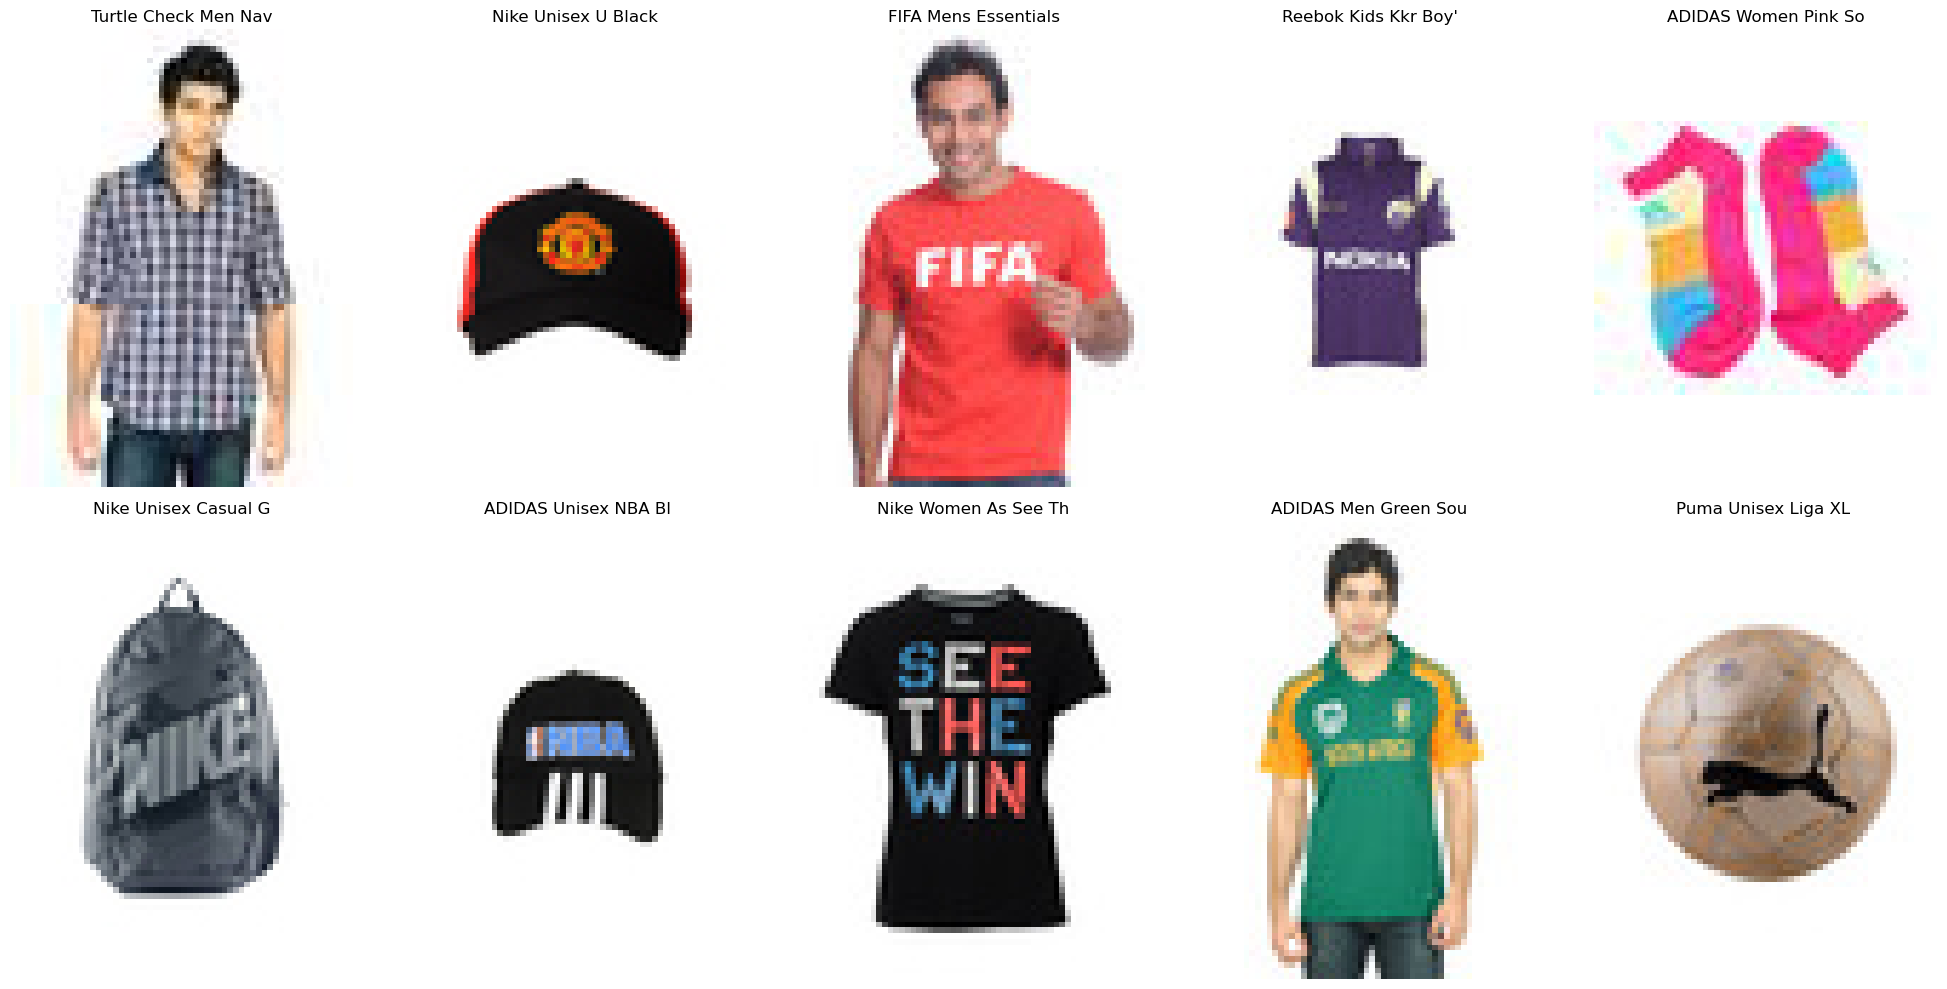

In [79]:
plt.figure(figsize=(20,10))

top_catalogs = catalog_df.head(10)

for i, row in enumerate(
    top_catalogs.itertuples()
):

    representative = metadata[
        metadata["cluster"]
        ==
        row.Catalog_ID
    ].iloc[0]

    image = Image.open(
        representative[
            "image_path"
        ]
    )

    plt.subplot(2,5,i+1)

    plt.imshow(image)

    plt.title(
        row.Catalog_Name[:20]
    )

    plt.axis("off")

plt.tight_layout()

plt.show()

##Reverse Product Search
##Architecture: Text Query -> CLIP Text Encoder -> Text Embedding -> FAISS Search -> Top-k Matching Products

In [59]:
from transformers import CLIPProcessor
from transformers import CLIPModel

import torch
import faiss
import numpy as np

In [60]:
model = CLIPModel.from_pretrained(
    "openai/clip-vit-base-patch32"
)

processor = CLIPProcessor.from_pretrained(
    "openai/clip-vit-base-patch32"
)

In [62]:
index = faiss.read_index(
    "fashion_index.faiss"
)

In [65]:
def encode_text(query):

    inputs = processor(
        text=[query],
        return_tensors="pt",
        padding=True
    )

    with torch.no_grad():

        features = model.get_text_features(
            **inputs
        )

    embedding = features.numpy()

    embedding = (
        embedding
        /
        np.linalg.norm(
            embedding
        )
    )

    return embedding.astype(
        "float32"
    )

In [66]:
metadata = pd.read_csv(
    "product_metadata.csv"
)

query = "blue casual shirt"

query_embedding = encode_text(query)

distances, indices = index.search(
    query_embedding,
    5
)

results = indices[0]

for rank, (idx, score) in enumerate(
    zip(results, distances[0])
):

    print(
        f"{rank+1}. "
        f"{metadata.iloc[idx]['productName']}"
        f" | Score: {score:.4f}"
    )

1. Wrangler Men Multi Blue Shirt | Score: 0.2937
2. Peter England Men Check Navy Blue Shirt | Score: 0.2917
3. Highlander Men Check Blue Shirt | Score: 0.2915
4. U.S. Polo Assn. Men Solid Blue Shirt | Score: 0.2908
5. Scullers For Her Check Blue Shirt | Score: 0.2904


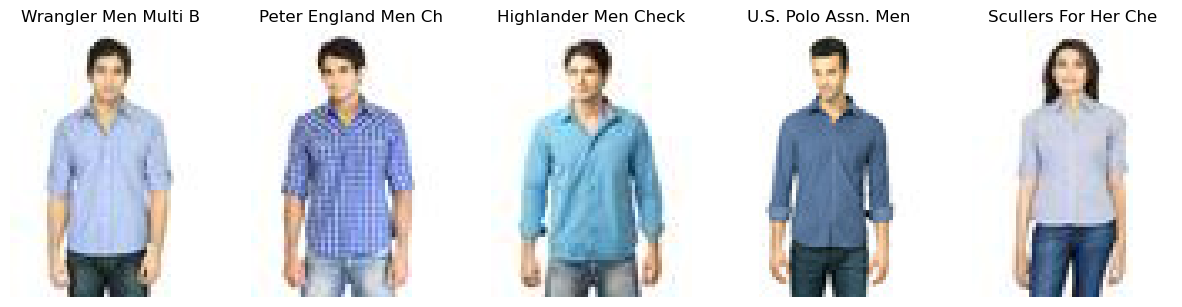

In [80]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i, idx in enumerate(results):

    product = metadata.iloc[idx]

    image = Image.open(
        product["image_path"]
    )

    plt.subplot(1,5,i+1)

    plt.imshow(image)

    plt.title(
        product["productName"][:20]
    )

    plt.axis("off")

plt.show()